# DeepLense: Model Training and Evaluation Demo
This notebook demonstrates the end-to-end training pipeline for the DeepLense project. 
Instead of running the CLI module (`uv run -m scripts.train`), we programmatically load the Hydra configuration, instantiate the `Trainer`, run a short demonstration training loop, and extract the resulting metrics and artifacts directly from MLflow.

I will begin with the results of the best training run and then show a demo of how the pipeline works

In [28]:
import os
import sys
from pathlib import Path

print(f"Original CWD: {os.getcwd()}")

os.chdir("../..")
sys.path.append(os.getcwd())
    
print(f"New CWD: {os.getcwd()}")

Original CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion
New CWD: d:\


In [ ]:
import os
import torch
import mlflow
import matplotlib.pyplot as plt
from hydra import initialize, compose
from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.10.0+cu126
CUDA Available: True


Fetching Final Results from MLflow Run: 87dac1155c2c4e00a65ba0abd2bb6120

Final Validation ROC AUC: 0.8962
Final Validation Accuracy: 0.7448



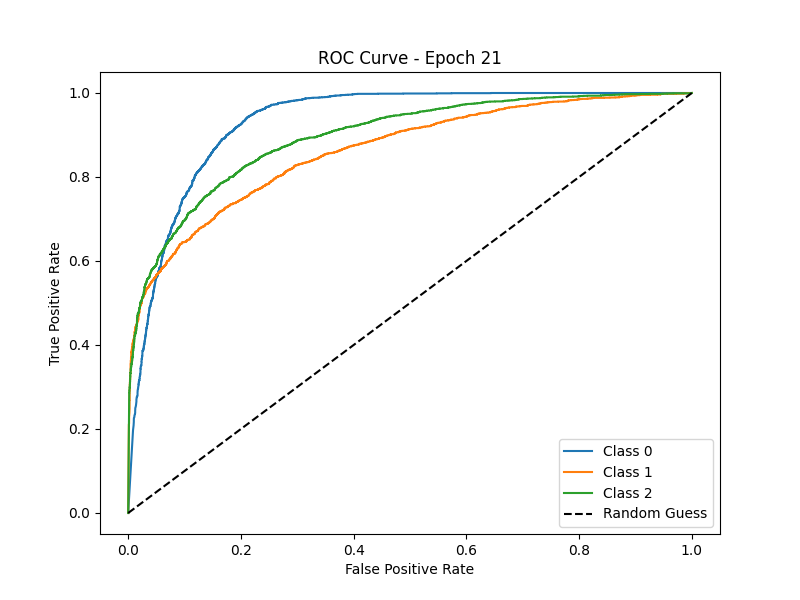

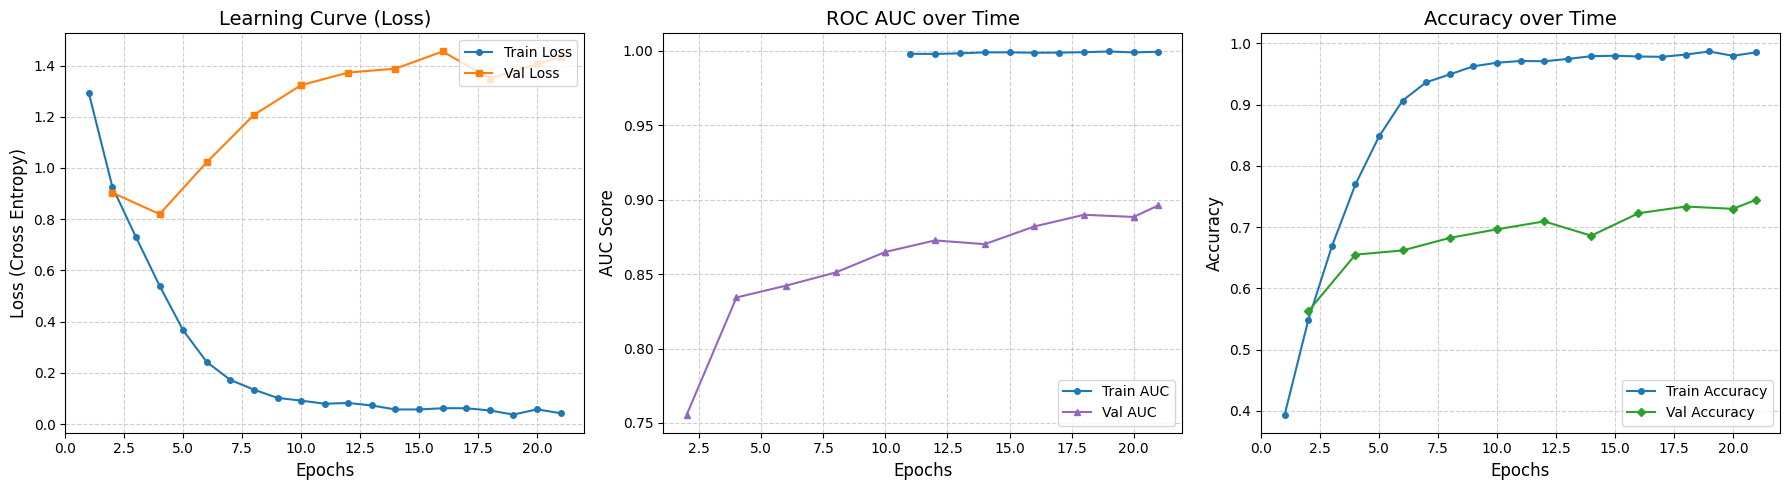

In [ ]:
import tempfile

BEST_RUN_ID = "87dac1155c2c4e00a65ba0abd2bb6120"
client = mlflow.tracking.MlflowClient()

print(f"Fetching Final Results from MLflow Run: {BEST_RUN_ID}\n")

def fetch_metric(metric_name):
    try:
        history = client.get_metric_history(BEST_RUN_ID, metric_name)
        return [m.step for m in history], [m.value for m in history]
    except Exception:
        return [], []

# Fetch metrics
epochs_tl, train_loss = fetch_metric("avg_loss")
epochs_vl, val_loss = fetch_metric("val_avg_loss")

epochs_ta, train_auc = fetch_metric("roc_auc")
epochs_va, val_auc = fetch_metric("val_roc_auc")

epochs_tacc, train_acc = fetch_metric("accuracy")
epochs_vacc, val_acc = fetch_metric("val_accuracy")

final_auc = val_auc[-1] if val_auc else "N/A"
final_acc = val_acc[-1] if val_acc else "N/A"

print(f"Final Validation ROC AUC: {final_auc:.4f}")
if final_acc != "N/A":
    print(f"Final Validation Accuracy: {final_acc:.4f}\n")

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        artifact_path = "validation_metrics/roc_curve_epoch_21.png" 
        local_path = client.download_artifacts(BEST_RUN_ID, artifact_path, tmp_dir)
        display(Image(filename=local_path))
    except Exception as e:
        print(f"Could not load the final ROC curve artifact: {e}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss
if train_loss and val_loss:
    axes[0].plot(epochs_tl, train_loss, label="Train Loss", color="tab:blue", marker="o", markersize=4)
    axes[0].plot(epochs_vl, val_loss, label="Val Loss", color="tab:orange", marker="s", markersize=4)
    axes[0].set_title("Learning Curve (Loss)", fontsize=14)
    axes[0].set_xlabel("Epochs", fontsize=12)
    axes[0].set_ylabel("Loss (Cross Entropy)", fontsize=12)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: ROC AUC
if train_auc and val_auc:
    axes[1].plot(epochs_ta, train_auc, label="Train AUC", color="tab:blue", marker="o", markersize=4)
    axes[1].plot(epochs_va, val_auc, label="Val AUC", color="tab:purple", marker="^", markersize=5)
    axes[1].set_title("ROC AUC over Time", fontsize=14)
    axes[1].set_xlabel("Epochs", fontsize=12)
    axes[1].set_ylabel("AUC Score", fontsize=12)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot 3: Accuracy
if train_acc and val_acc:
    axes[2].plot(epochs_tacc, train_acc, label="Train Accuracy", color="tab:blue", marker="o", markersize=4)
    axes[2].plot(epochs_vacc, val_acc, label="Val Accuracy", color="tab:green", marker="D", markersize=4)
    axes[2].set_title("Accuracy over Time", fontsize=14)
    axes[2].set_xlabel("Epochs", fontsize=12)
    axes[2].set_ylabel("Accuracy", fontsize=12)
    axes[2].legend(loc="lower right")
    axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [19]:
# Initialize Hydra and load the config
with initialize(version_base=None, config_path=f"../../configs"):
    # We can override config values right here, just like in the terminal
    # We set epochs to 2 for a quick demonstration.
    cfg = compose(config_name="config", overrides=["training.epochs=2", "sampling.sample_every_n_epochs=1"])

print("Active Configuration Configuration:")
print(f"Model: {cfg.model.name} ({cfg.model.type})")
print(f"Dataset: {cfg.dataset.name}")
print(f"Epochs: {cfg.training.epochs}")

Active Configuration Configuration:
Model: efficient_net_b2 (classifier)
Dataset: deeplense_classify
Epochs: 2


In [20]:
from src.data import get_dataloaders, get_datasets, get_stats as get_stats_fn
from src.data.config import DataConfig
from src.models import get_model
from src.training.trainer import Trainer
from src.metrics import get_metric

# Load Data
data_config = DataConfig(**cfg.dataset)
train_dataset, test_dataset = get_datasets(data_config)
train_loader, test_loader = get_dataloaders(data_config)
get_stats = get_stats_fn(data_config)

# Load Model
model = get_model(cfg)

# Load Metrics
metrics = {}
for metric_cfg in cfg.model.metrics.values():
    metrics[metric_cfg.name] = get_metric(metric_cfg, cfg)

# Setup Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.training.lr)

# Initialize Trainer
trainer = Trainer(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    test_dataset=test_dataset,
    optimizer=optimizer,
    get_stats=get_stats,
    config=cfg,
    start_epoch=1,
    metrics=metrics
)

Loading dataset: deeplense_classify
Loading dataset: deeplense_classify
Trainer initialized for mode: CLASSIFIER
EMA enabled with decay rate: 0.9999


Fetching a fixed sample batch from the dataloader...


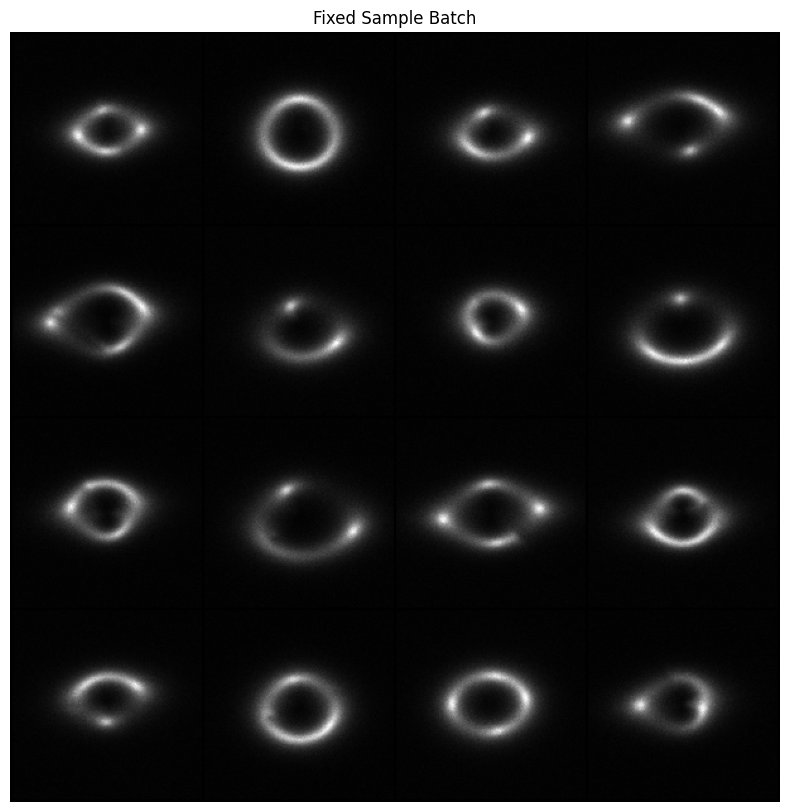

In [21]:
# Visualize what the model is about to see
print("Fetching a fixed sample batch from the dataloader...")
trainer.plot_fixed_batch()

In [22]:
# Start the MLflow run
mlflow.set_experiment(cfg.experiment_name)

with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"Started MLflow Run ID: {run_id}")
    
    # Run short 2-epoch demo
    trainer.train()
    
print("Demonstration training complete!")

Started MLflow Run ID: 7f05fb809c474509a4f86144dbda5b2e
Starting training from epoch 1...


Epoch 1: 100%|██████████| 469/469 [02:29<00:00,  3.14it/s, loss=0.996]


Epoch 1 - accuracy: 0.3810
Epoch 1 - roc_auc: 0.5521
Epoch 1 - Average loss: 1.3318
Logged checkpoints for epoch 1 to MLFlow


val_1: 100%|██████████| 118/118 [00:08<00:00, 13.63it/s]


Validation - Epoch 1 - accuracy: 0.4613
Validation - Epoch 1 - roc_auc: 0.6483
Logged ROC curve for epoch 1 to MLFlow
Average validation loss: 1.0329233372615556


...

Validation - Epoch 2 - accuracy: 0.5357
Validation - Epoch 2 - roc_auc: 0.7376
Logged ROC curve for epoch 2 to MLFlow
Average validation loss: 0.9361885412264679


2026/03/13 00:08:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/13 00:08:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/13 00:08:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Final EMA model saved in MLFlow model format
Logged checkpoints for epoch 2 to MLFlow


val_2: 100%|██████████| 118/118 [00:08<00:00, 13.81it/s]


Validation - Epoch 2 - accuracy: 0.5357
Validation - Epoch 2 - roc_auc: 0.7376
Logged ROC curve for epoch 2 to MLFlow
Average validation loss: 0.9361885412264679
Training complete.
Demonstration training complete!


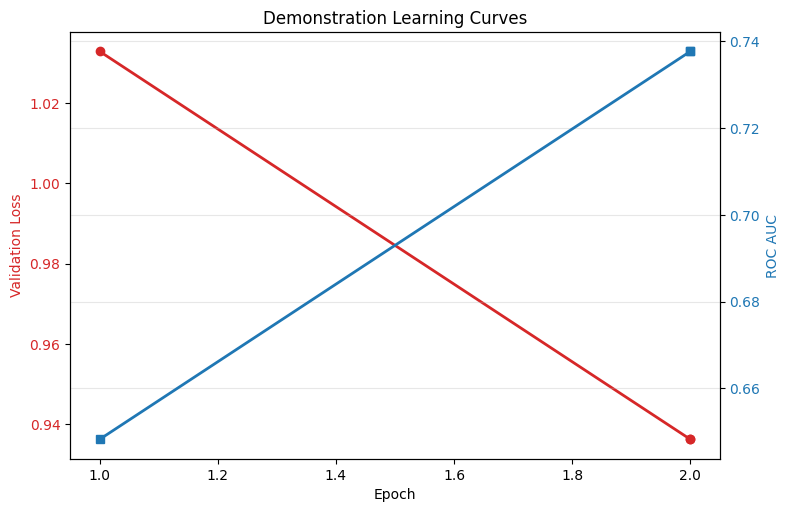

In [23]:
# Fetch the metric history for the run we just completed
client = mlflow.tracking.MlflowClient()

# Extract Validation Loss and ROC AUC
try:
    loss_history = client.get_metric_history(run_id, "val_avg_loss")
    auc_history = client.get_metric_history(run_id, "val_roc_auc")
    
    epochs = [m.step for m in loss_history]
    losses = [m.value for m in loss_history]
    aucs = [m.value for m in auc_history]

    # Plot the learning curves
    fig, ax1 = plt.subplots(figsize=(8, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Validation Loss', color=color)
    ax1.plot(epochs, losses, color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('ROC AUC', color=color)  
    ax2.plot(epochs, aucs, color=color, marker='s', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  
    plt.title("Demonstration Learning Curves")
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print(f"Could not fetch metric history: {e}")

Latest ROC Curve from MLflow Artifacts:


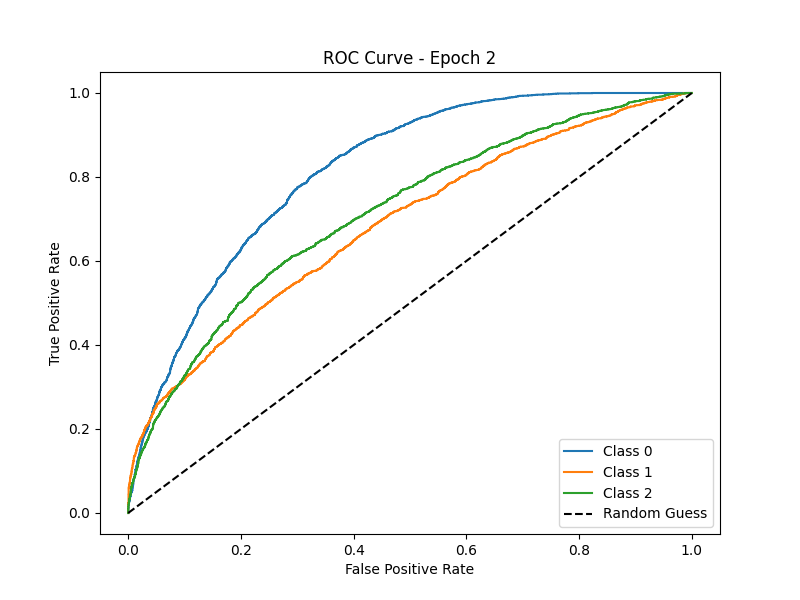

In [29]:
# Download the ROC curve image generated by the trainer and display it directly
import tempfile

with tempfile.TemporaryDirectory() as tmp_dir:
    # Download the specific artifact
    artifact_path = "validation_metrics/roc_curve_epoch_2.png"
    local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
    
    print("Latest ROC Curve from MLflow Artifacts:")
    display(Image(filename=local_path))